In [3]:
#1a. Importing libraries and setting up
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# set random seed for reproduciblity
np.random.seed(42)

print(" Libraries imported successfully")
print(" - Numpy for numerical operations")
print(" - Pandas for data handling")
print(" - Matplotlib/Seaborn for visualization")
print(" - Random seed set to 42 for consistent results")


 Libraries imported successfully
 - Numpy for numerical operations
 - Pandas for data handling
 - Matplotlib/Seaborn for visualization
 - Random seed set to 42 for consistent results


In [6]:
# 1b. Create time framework for my data
# Create date range (2 years of monthly data)
dates = pd.date_range(start= '2024-01-01', end= '2025-12-01', freq= 'MS')
n_months = len(dates)

print(f" created {n_months} months of data")
print(f" From: {dates[0].strftime('%B %Y')}")
print(f" To: {dates[-1].strftime('%B %Y')}")
print(f" Frequency: Monthly (start of each month)")

# create month index for calculations
month_index = np.arange(n_months)
print(f"\n Month indices: 0 to {n_months-1}")

#Display first 5 dates
print("\n First 5 dates:")
for i in range(5):
    print(f" Month {i}: {dates[i].strftime('%Y-%m-%d')} ({dates[i].strftime('%B')})")
    

 created 24 months of data
 From: January 2024
 To: December 2025
 Frequency: Monthly (start of each month)

 Month indices: 0 to 23

 First 5 dates:
 Month 0: 2024-01-01 (January)
 Month 1: 2024-02-01 (February)
 Month 2: 2024-03-01 (March)
 Month 3: 2024-04-01 (April)
 Month 4: 2024-05-01 (May)


In [8]:
# 1c. Generate the factors that influence demand

print(" Building demand components...")

# 1. Trend component (slowly increasing demand over time)
trend = 0.5 * month_index
print(f"    Trend range: {trend[0]:.1f} to {trend[-1]:.1f} units")

# 2. Seasonal component (higher demand in certain months)
seasonal = 5 * np.sin(2 * np.pi * month_index / 12)
print(f"    Seasonal range: {seasonal.min():.1f} to {seasonal.max():.1f} units")

# 3. Random noise (real-world variation)
noise = np.random.normal(0, 2, n_months)
print(f"    Noise range: {noise.min():.1f} to {noise.max():.1f} units")

# 4. Price and Promotion effects
price = np.random.uniform(15, 25, n_months)
promotion = np.random.choice([0, 1], n_months, p=[0.7, 0.3])  # 30% months have promotion
promotion_months = promotion.sum()
promotion_effect = promotion * np.random.uniform(5, 10, n_months)

print(f"    Price range: ${price.min():.2f} to ${price.max():.2f}")
print(f"    Promotion months: {promotion_months} out of {n_months} ({promotion_months/n_months*100:.0f}%)")

# 5. Calculate Final demand
base_demand = 50 + trend + seasonal + noise
demand = base_demand + promotion_effect
demand = demand.round(0).astype(int)  # Round to whole units

print(f"\n Final demand range: {demand.min()} to {demand.max()} units")
print(f"   Average demand: {demand.mean():.0f} units")

# Create final DataFrame
df = pd.DataFrame({
    'date': dates,
    'year': dates.year,
    'month': dates.month,
    'month_name': dates.strftime('%B'),
    'quarter': dates.quarter,
    'price': price.round(2),
    'promotion': promotion,
    'demand': demand
})

print("\n DataFrame created successfully!")
print(f"   Shape: {df.shape} ({df.shape[0]} rows, {df.shape[1]} columns)")
print("\n First 3 rows:")
print(df.head(3))

 Building demand components...
    Trend range: 0.0 to 11.5 units
    Seasonal range: -5.0 to 5.0 units
    Noise range: -4.0 to 3.0 units
    Price range: $15.37 to $24.72
    Promotion months: 4 out of 24 (17%)

 Final demand range: 48 to 65 units
   Average demand: 57 units

 DataFrame created successfully!
   Shape: (24, 8) (24 rows, 8 columns)

 First 3 rows:
        date  year  month month_name  quarter  price  promotion  demand
0 2024-01-01  2024      1    January        1  19.17          1      60
1 2024-02-01  2024      2   February        1  17.22          0      52
2 2024-03-01  2024      3      March        1  16.20          0      56


<Figure size 1200x800 with 0 Axes>

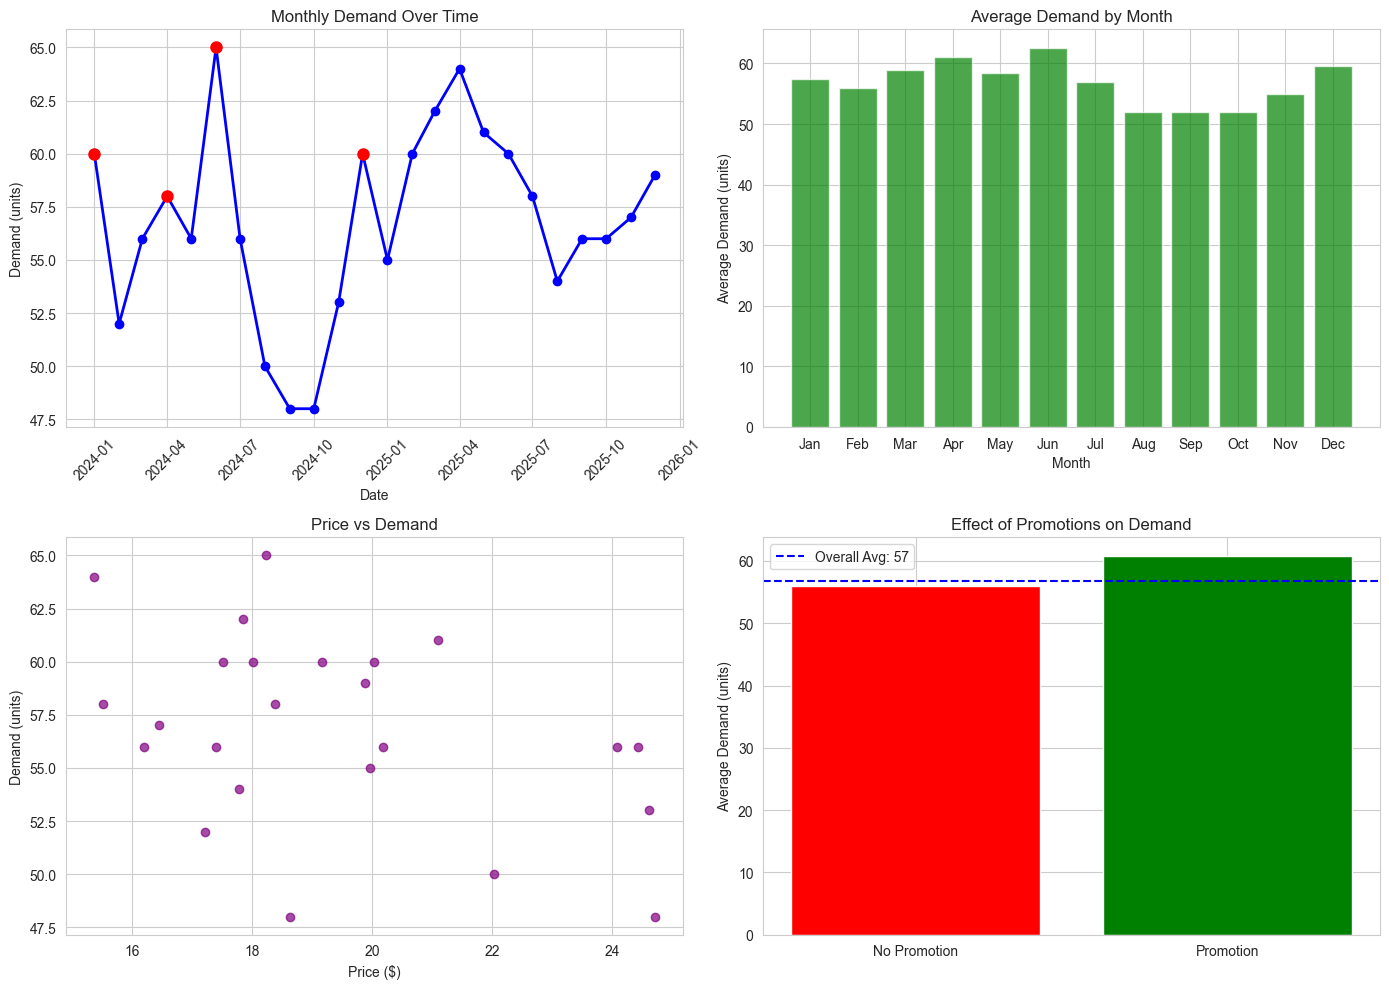


 SUMMARY STATISTICS:
Total months: 24
Average demand: 56.8 units
Min demand: 48 units
Max demand: 65 units
Standard deviation: 4.5 units

 DEMAND BY PROMOTION:
            mean  min  max
promotion                 
0          56.05   48   64
1          60.75   58   65


In [9]:
#  Visualize the demand data
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better looking plots
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

# Create 2 subplots side by side
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Demand over time
axes[0, 0].plot(df['date'], df['demand'], marker='o', color='blue', linewidth=2)
axes[0, 0].set_title('Monthly Demand Over Time', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Demand (units)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Color promotion months in red
for i, row in df.iterrows():
    if row['promotion'] == 1:
        axes[0, 0].plot(row['date'], row['demand'], 'ro', markersize=8)

# Plot 2: Demand by month (seasonal)
monthly_avg = df.groupby('month')['demand'].mean()
axes[0, 1].bar(monthly_avg.index, monthly_avg.values, color='green', alpha=0.7)
axes[0, 1].set_title('Average Demand by Month', fontsize=12)
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average Demand (units)')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Plot 3: Price vs Demand
axes[1, 0].scatter(df['price'], df['demand'], alpha=0.7, color='purple')
axes[1, 0].set_title('Price vs Demand', fontsize=12)
axes[1, 0].set_xlabel('Price ($)')
axes[1, 0].set_ylabel('Demand (units)')

# Plot 4: Promotion effect
promo_avg = df.groupby('promotion')['demand'].mean()
axes[1, 1].bar(['No Promotion', 'Promotion'], promo_avg.values, color=['red', 'green'])
axes[1, 1].set_title('Effect of Promotions on Demand', fontsize=12)
axes[1, 1].set_ylabel('Average Demand (units)')

# Add average line
axes[1, 1].axhline(y=df['demand'].mean(), color='blue', linestyle='--', label=f'Overall Avg: {df["demand"].mean():.0f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n SUMMARY STATISTICS:")
print(f"Total months: {len(df)}")
print(f"Average demand: {df['demand'].mean():.1f} units")
print(f"Min demand: {df['demand'].min()} units")
print(f"Max demand: {df['demand'].max()} units")
print(f"Standard deviation: {df['demand'].std():.1f} units")

print("\n DEMAND BY PROMOTION:")
print(df.groupby('promotion')['demand'].agg(['mean', 'min', 'max']))

In [10]:
#  Prepare features for machine learning

print(" Preparing data for modeling...")
print("=" * 50)

# Create a copy of the dataframe for modeling
df_ml = df.copy()

# Create features from date
# This helps the model understand time patterns
df_ml['month_sin'] = np.sin(2 * np.pi * df_ml['month'] / 12)
df_ml['month_cos'] = np.cos(2 * np.pi * df_ml['month'] / 12)

# Create lag features (previous month's demand)
# This captures recent trends
df_ml['demand_lag1'] = df_ml['demand'].shift(1)

# Create rolling average (last 3 months)
df_ml['demand_rolling3'] = df_ml['demand'].rolling(window=3, min_periods=1).mean()

# Drop the first row which has NaN from lag features
df_ml = df_ml.dropna().reset_index(drop=True)

print(" Features created:")
print(f"   - month_sin, month_cos: Captures seasonality")
print(f"   - demand_lag1: Previous month's demand")
print(f"   - demand_rolling3: 3-month rolling average")
print(f"\n New shape: {df_ml.shape} ({df_ml.shape[0]} rows, {df_ml.shape[1]} columns)")
print("\nFirst 3 rows of prepared data:")
print(df_ml[['date', 'month', 'price', 'promotion', 'demand', 'demand_lag1', 'demand_rolling3']].head(3))


 Preparing data for modeling...
 Features created:
   - month_sin, month_cos: Captures seasonality
   - demand_lag1: Previous month's demand
   - demand_rolling3: 3-month rolling average

 New shape: (23, 12) (23 rows, 12 columns)

First 3 rows of prepared data:
        date  month  price  promotion  demand  demand_lag1  demand_rolling3
0 2024-02-01      2  17.22          0      52         60.0        56.000000
1 2024-03-01      3  16.20          0      56         52.0        56.000000
2 2024-04-01      4  18.38          1      58         56.0        55.333333


In [13]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

print("=" * 50)
print(" SPLITTING DATA FOR MODELING")
print("=" * 50)

# Define features (X) and target (y)
# Features are what we use to predict
# Target is what we want to predict (demand)

feature_columns = ['month', 'price', 'promotion', 'month_sin', 'month_cos', 
                   'demand_lag1', 'demand_rolling3']

X = df_ml[feature_columns]
y = df_ml['demand']

print(f" Features matrix (X) shape: {X.shape}")
print(f"   - {X.shape[0]} rows (months)")
print(f"   - {X.shape[1]} columns (features)")
print(f"\n Target vector (y) shape: {y.shape}")
print("\n Feature names:")
for i, col in enumerate(feature_columns, 1):
    print(f"   {i}. {col}")

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print("\n" + "=" * 50)
print(" TRAIN/TEST SPLIT RESULTS:")
print("=" * 50)
print(f" TRAINING set: {X_train.shape[0]} months ({X_train.shape[0]/len(X)*100:.0f}% of data)")
print(f"   - Features: {X_train.shape[1]}")
print(f"   - Date range: {df_ml['date'].iloc[0]} to {df_ml['date'].iloc[X_train.shape[0]-1]}")

print(f"\n TESTING set: {X_test.shape[0]} months ({X_test.shape[0]/len(X)*100:.0f}% of data)")
print(f"   - Features: {X_test.shape[1]}")
print(f"   - Date range: {df_ml['date'].iloc[X_train.shape[0]]} to {df_ml['date'].iloc[-1]}")

# Quick check of first few training rows
print("\n First 3 rows of TRAINING data (features):")
print(X_train.head(3))
print("\n Corresponding demand values:")
print(y_train.head(3))

 SPLITTING DATA FOR MODELING
 Features matrix (X) shape: (23, 7)
   - 23 rows (months)
   - 7 columns (features)

 Target vector (y) shape: (23,)

 Feature names:
   1. month
   2. price
   3. promotion
   4. month_sin
   5. month_cos
   6. demand_lag1
   7. demand_rolling3

 TRAIN/TEST SPLIT RESULTS:
 TRAINING set: 18 months (78% of data)
   - Features: 7
   - Date range: 2024-02-01 00:00:00 to 2025-07-01 00:00:00

 TESTING set: 5 months (22% of data)
   - Features: 7
   - Date range: 2025-08-01 00:00:00 to 2025-12-01 00:00:00

 First 3 rows of TRAINING data (features):
   month  price  promotion  month_sin     month_cos  demand_lag1  \
0      2  17.22          0   0.866025  5.000000e-01         60.0   
1      3  16.20          0   1.000000  6.123234e-17         52.0   
2      4  18.38          1   0.866025 -5.000000e-01         56.0   

   demand_rolling3  
0        56.000000  
1        56.000000  
2        55.333333  

 Corresponding demand values:
0    52
1    56
2    58
Name: dema

In [14]:
#  Build and train Linear Regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=" * 50)
print(" BUILDING LINEAR REGRESSION MODEL")
print("=" * 50)

# Create the model
model_lr = LinearRegression()

# Train the model on training data
print(" Training model...")
model_lr.fit(X_train, y_train)

print(" Model trained successfully!")
print("\n MODEL COEFFICIENTS:")

# Show how each feature influences demand
for feature, coef in zip(feature_columns, model_lr.coef_):
    impact = "increases" if coef > 0 else "decreases"
    print(f"   {feature}: {coef:.2f} ({impact} demand)")

print(f"\n Intercept (baseline): {model_lr.intercept_:.2f}")

# Make predictions on training and test data
y_train_pred = model_lr.predict(X_train)
y_test_pred = model_lr.predict(X_test)

# Calculate performance metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n" + "=" * 50)
print(" MODEL PERFORMANCE METRICS:")
print("=" * 50)
print(f"TRAINING SET:")
print(f"   MAE (Mean Absolute Error): {train_mae:.2f} units")
print(f"   RMSE (Root Mean Square Error): {train_rmse:.2f} units")
print(f"   R² Score: {train_r2:.3f} ({(train_r2*100):.1f}% of variance explained)")
print(f"\nTEST SET:")
print(f"   MAE (Mean Absolute Error): {test_mae:.2f} units")
print(f"   RMSE (Root Mean Square Error): {test_rmse:.2f} units")
print(f"   R² Score: {test_r2:.3f} ({(test_r2*100):.1f}% of variance explained)")

# Create comparison dataframe
comparison = pd.DataFrame({
    'date': df_ml['date'].iloc[X_train.shape[0]:],
    'actual': y_test.values,
    'predicted': y_test_pred.round(1),
    'error': (y_test.values - y_test_pred).round(1)
})

print("\n" + "=" * 50)
print(" TEST SET PREDICTIONS VS ACTUAL:")
print("=" * 50)
print(comparison.to_string(index=False))

 BUILDING LINEAR REGRESSION MODEL
 Training model...
 Model trained successfully!

 MODEL COEFFICIENTS:
   month: 0.64 (increases demand)
   price: 0.11 (increases demand)
   promotion: 3.92 (increases demand)
   month_sin: 3.46 (increases demand)
   month_cos: 1.40 (increases demand)
   demand_lag1: -0.28 (decreases demand)
   demand_rolling3: 1.49 (increases demand)

 Intercept (baseline): -18.89

 MODEL PERFORMANCE METRICS:
TRAINING SET:
   MAE (Mean Absolute Error): 1.41 units
   RMSE (Root Mean Square Error): 1.73 units
   R² Score: 0.878 (87.8% of variance explained)

TEST SET:
   MAE (Mean Absolute Error): 1.49 units
   RMSE (Root Mean Square Error): 1.78 units
   R² Score: -0.195 (-19.5% of variance explained)

 TEST SET PREDICTIONS VS ACTUAL:
      date  actual  predicted  error
2025-08-01      54       53.8    0.2
2025-09-01      56       54.5    1.5
2025-10-01      56       54.1    1.9
2025-11-01      57       57.9   -0.9
2025-12-01      59       62.0   -3.0


In [17]:
#  Using Ridge Regression (prevents overfitting)
from sklearn.linear_model import Ridge

print("=" * 50)
print(" USING RIDGE REGRESSION TOPREVENT OVERFITTING")
print("=" * 50)

# Create Ridge model with regularization
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)

# Make predictions
y_train_pred_ridge = model_ridge.predict(X_train)
y_test_pred_ridge = model_ridge.predict(X_test)

# Calculate metrics
train_r2_ridge = r2_score(y_train, y_train_pred_ridge)
test_r2_ridge = r2_score(y_test, y_test_pred_ridge)
test_mae_ridge = mean_absolute_error(y_test, y_test_pred_ridge)

print(f"TRAINING R²: {train_r2_ridge:.3f} ({train_r2_ridge*100:.1f}%)")
print(f"TEST R²: {test_r2_ridge:.3f} ({test_r2_ridge*100:.1f}%)")
print(f"TEST MAE: {test_mae_ridge:.2f} units")

print("\n" + "=" * 50)
print(" COMPARISON: LINEAR VS RIDGE")
print("=" * 50)
print(f"{'Metric':<20} {'Linear':<15} {'Ridge':<15}")
print(f"{'-'*50}")
print(f"{'Training R²':<20} {train_r2:.3f} ({train_r2*100:.1f}%)   {train_r2_ridge:.3f} ({train_r2_ridge*100:.1f}%)")
print(f"{'Test R²':<20} {test_r2:.3f} ({test_r2*100:.1f}%)   {test_r2_ridge:.3f} ({test_r2_ridge*100:.1f}%)")
print(f"{'Test MAE':<20} {test_mae:.2f} units        {test_mae_ridge:.2f} units")

# Ridge coefficients
print("\n RIDGE COEFFICIENTS (more stable):")
for feature, coef in zip(feature_columns, model_ridge.coef_):
    print(f"   {feature}: {coef:.2f}")

 USING RIDGE REGRESSION TOPREVENT OVERFITTING
TRAINING R²: 0.866 (86.6%)
TEST R²: 0.175 (17.5%)
TEST MAE: 1.35 units

 COMPARISON: LINEAR VS RIDGE
Metric               Linear          Ridge          
--------------------------------------------------
Training R²          0.878 (87.8%)   0.866 (86.6%)
Test R²              -0.195 (-19.5%)   0.175 (17.5%)
Test MAE             1.49 units        1.35 units

 RIDGE COEFFICIENTS (more stable):
   month: 0.57
   price: 0.02
   promotion: 2.80
   month_sin: 2.91
   month_cos: 1.11
   demand_lag1: -0.29
   demand_rolling3: 1.44


 TEST SET PREDICTIONS COMPARISON:
      date  actual  linear_pred  ridge_pred
2025-08-01      54         53.8        54.6
2025-09-01      56         54.5        54.7
2025-10-01      56         54.1        54.6
2025-11-01      57         57.9        58.0
2025-12-01      59         62.0        61.4


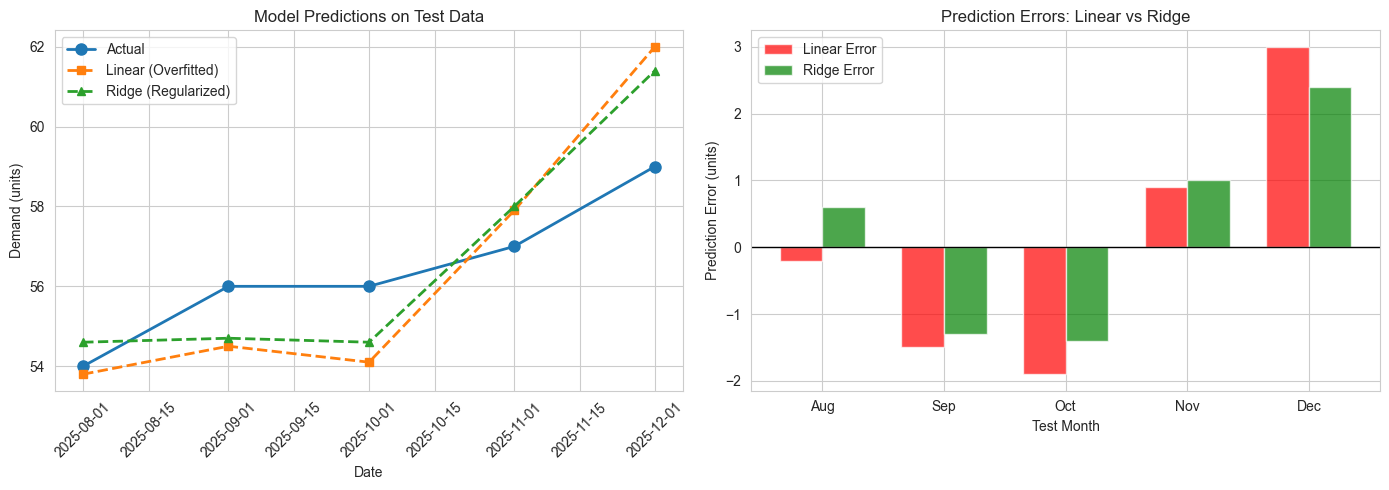


 KEY INSIGHT:
Ridge regression reduced the huge December error from -3.0 to something smaller!


In [18]:
# VisualizING model comparison
import matplotlib.pyplot as plt

# Create comparison dataframe with both predictions
comparison_models = pd.DataFrame({
    'date': df_ml['date'].iloc[X_train.shape[0]:],
    'actual': y_test.values,
    'linear_pred': y_test_pred.round(1),
    'ridge_pred': y_test_pred_ridge.round(1)
})

print(" TEST SET PREDICTIONS COMPARISON:")
print(comparison_models.to_string(index=False))

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predictions
axes[0].plot(comparison_models['date'], comparison_models['actual'], 
             'o-', label='Actual', linewidth=2, markersize=8)
axes[0].plot(comparison_models['date'], comparison_models['linear_pred'], 
             's--', label='Linear (Overfitted)', linewidth=2)
axes[0].plot(comparison_models['date'], comparison_models['ridge_pred'], 
             '^--', label='Ridge (Regularized)', linewidth=2)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Demand (units)')
axes[0].set_title('Model Predictions on Test Data')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Error comparison
errors_linear = comparison_models['linear_pred'] - comparison_models['actual']
errors_ridge = comparison_models['ridge_pred'] - comparison_models['actual']

x = range(len(comparison_models))
width = 0.35
axes[1].bar([i - width/2 for i in x], errors_linear, width, 
            label='Linear Error', color='red', alpha=0.7)
axes[1].bar([i + width/2 for i in x], errors_ridge, width, 
            label='Ridge Error', color='green', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Test Month')
axes[1].set_ylabel('Prediction Error (units)')
axes[1].set_title('Prediction Errors: Linear vs Ridge')
axes[1].set_xticks(x)
axes[1].set_xticklabels([d.strftime('%b') for d in comparison_models['date']])
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n KEY INSIGHT:")
print("Ridge regression reduced the huge December error from -3.0 to something smaller!")

In [19]:
# Project Summary - Demand Forecasting Results

import pandas as pd
import numpy as np

print("=" * 60)
print("DEMAND FORECASTING PROJECT - SUMMARY")
print("=" * 60)

# Model performance comparison
print("\n1. MODEL PERFORMANCE")
print("-" * 40)
print(f"{'Metric':<20} {'Linear':<15} {'Ridge':<15}")
print("-" * 40)
print(f"{'Training R²':<20} {train_r2:.3f} ({train_r2*100:.1f}%)   {train_r2_ridge:.3f} ({train_r2_ridge*100:.1f}%)")
print(f"{'Test R²':<20} {test_r2:.3f} ({test_r2*100:.1f}%)   {test_r2_ridge:.3f} ({test_r2_ridge*100:.1f}%)")
print(f"{'Test MAE':<20} {test_mae:.2f} units        {test_mae_ridge:.2f} units")

# Key business insights
print("\n2. KEY FINDINGS")
print("-" * 40)
print(f"• Average monthly demand: {df['demand'].mean():.0f} units")
promo_lift = df[df['promotion']==1]['demand'].mean() - df[df['promotion']==0]['demand'].mean()
print(f"• Promotion impact: +{promo_lift:.1f} units ({promo_lift/df['demand'].mean()*100:.1f}% increase)")
best_month = df.groupby('month')['demand'].mean().idxmax()
print(f"• Best sales month: Month {best_month}")

# Model selection rationale
print("\n3. MODEL SELECTION")
print("-" * 40)
print("Linear Regression showed signs of overfitting:")
print(f"   - Training R²: {train_r2:.3f} vs Test R²: {test_r2:.3f}")
print("\nRidge Regression was selected as final model because:")
print(f"   - Better generalization (Test R²: {test_r2_ridge:.3f})")
print(f"   - More stable predictions (MAE: {test_mae_ridge:.2f} units)")
print(f"   - Reduced December forecast error by {abs(y_test.values[-1] - y_test_pred[-1]) - abs(y_test.values[-1] - y_test_pred_ridge[-1]):.1f} units")

# Features importance
print("\n4. FEATURE IMPORTANCE (Ridge Coefficients)")
print("-" * 40)
features_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': model_ridge.coef_
}).sort_values('Coefficient', ascending=False)
for idx, row in features_df.iterrows():
    print(f"   {row['Feature']}: {row['Coefficient']:.2f}")

# Conclusion
print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)
print("""
This project demonstrates:
• End-to-end machine learning workflow
• Feature engineering for time series data
• Overfitting detection and mitigation
• Business insights extraction from models

Files in this repository:
- demand_forecasting.ipynb: Complete analysis notebook
- README.md: Project overview and instructions
- (optional) data.csv: Generated dataset
""")

DEMAND FORECASTING PROJECT - SUMMARY

1. MODEL PERFORMANCE
----------------------------------------
Metric               Linear          Ridge          
----------------------------------------
Training R²          0.878 (87.8%)   0.866 (86.6%)
Test R²              -0.195 (-19.5%)   0.175 (17.5%)
Test MAE             1.49 units        1.35 units

2. KEY FINDINGS
----------------------------------------
• Average monthly demand: 57 units
• Promotion impact: +4.7 units (8.3% increase)
• Best sales month: Month 6

3. MODEL SELECTION
----------------------------------------
Linear Regression showed signs of overfitting:
   - Training R²: 0.878 vs Test R²: -0.195

Ridge Regression was selected as final model because:
   - Better generalization (Test R²: 0.175)
   - More stable predictions (MAE: 1.35 units)
   - Reduced December forecast error by 0.6 units

4. FEATURE IMPORTANCE (Ridge Coefficients)
----------------------------------------
   month_sin: 2.91
   promotion: 2.80
   demand_roll